# 🌀 บทที่ 13 — Spectrum Width และการตรวจจับความปั่นป่วน (PyTDA / EDR)
### หลักสูตรแลปเรดาร์ตรวจอากาศด้วย Py-ART และ wradlib

**ระดับ:** ขั้นสูง  |  **ต้องมีก่อน:** รันบทที่ 00 แล้ว (ใช้ QC จากบท 03 และ dealias จากบท 09)

Spectrum width (ความกว้างสเปกตรัม) เป็นตัวแปรที่ถูกมองข้าม แต่ทรงพลังในการเผย **ความปั่นป่วน (turbulence)** และ **แรงเฉือนลม (wind shear)** บทนี้ให้นิสิตเข้าใจทฤษฎี เทียบกับ reflectivity/velocity และต่อยอดสู่การประเมิน **Eddy Dissipation Rate (EDR)** ด้วย **PyTDA (NASA)**

**เส้นเรื่องของบท (ร้อยเรียง):**
| # | หัวข้อ |
|---|---|
| A1 | Spectrum width PPI (หลัง QC) + การแปลผล |
| A2 | เทียบ reflectivity / velocity (dealiased) / spectrum width |
| A3 | บริเวณ SW สูง = ความปั่นป่วน/แรงเฉือน |
| A4 | ภาพตัดแนวดิ่งของ spectrum width |
| A5 | **PyTDA: คำนวณ EDR ด้วยคำสั่งเดียว** |
| A6 | 4-panel: refl / vel / SW / EDR (แบบ NASA demo) |
| A7 | จำแนกระดับความปั่นป่วน (เบา/ปานกลาง/รุนแรง) |
| A8 | สาธิตสมการ EDR–spectrum width |
| A9 | **เคสให้ทดลอง**: เทียบ 10:00 vs 10:30 + ปรับพารามิเตอร์ |
| A10 | ประยุกต์: แผนที่เตือนภัยความปั่นป่วน (การบิน) |

---


## 🧠 หลักการเบื้องต้น: Spectrum Width และ Turbulence

**Spectrum width** ($\sigma_v$, m/s) คือ **ส่วนเบี่ยงเบนมาตรฐานของสเปกตรัมความเร็วดอปเปลอร์** ภายในปริมาตรตรวจวัดหนึ่ง ๆ (ถ่วงน้ำหนักด้วยกำลังสะท้อน) พูดง่าย ๆ คือ "เป้าในปริมาตรนั้นเคลื่อนที่ด้วยความเร็วต่างกันมากแค่ไหน"

- ถ้าเป้าทุกตัวเคลื่อนที่พร้อมเพรียงกัน → $\sigma_v$ **ต่ำ** (สงบ)
- ถ้าความเร็วกระจายมาก (หมุนวน ลมกระโชก มวลอากาศปะทะกัน) → $\sigma_v$ **สูง**

องค์ประกอบของ spectrum width รวมกันแบบกำลังสอง:

$$\sigma_v^2 = \sigma_{turb}^2 + \sigma_{shear}^2 + \sigma_{antenna}^2 + \sigma_{fall}^2 + \sigma_{orient}^2$$

ที่เราสนใจทางอุตุนิยมคือ **$\sigma_{turb}$ (ความปั่นป่วน)** และ **$\sigma_{shear}$ (แรงเฉือน)**

**การแปลผล:** SW สูงบ่งชี้ turbulence/shear/แนวปะทะ/การหมุน (mesocyclone) — แต่ **ระวัง** SW สูงอาจมาจาก clutter/นก/สัญญาณอ่อนได้ด้วย จึงต้อง **QC ก่อน** และดูร่วมกับ reflectivity + velocity เสมอ

**Eddy Dissipation Rate (EDR, $\varepsilon$)** = อัตราการสลายพลังงานจลน์ของความปั่นป่วน นิยมใช้ $\varepsilon^{1/3}$ (m$^{2/3}$s$^{-1}$) เป็นมาตรฐานสากลวัดความปั่นป่วนสำหรับการบิน **PyTDA** ของ NASA แปลง spectrum width เป็น EDR ได้ (ทฤษฎี Labitt 1981; Bohne 1982; ค่าคงที่ Kolmogorov = 1.6)

> อ่านเพิ่ม: RainViewer — *Spectrum Width* (https://www.rainviewer.com/blog/pro-radar-spectrum-width.html) และ PyTDA (https://github.com/nasa/PyTDA)


## ⚙️ ส่วนหัวมาตรฐาน (ติดตั้งไลบรารี + เชื่อม Drive + ฟอนต์ไทย)

ติดตั้ง PyTDA จาก GitHub (ต้องมี Cython เพื่อ build) — ถ้าติดตั้งไม่สำเร็จ บทนี้จะใช้สมการ EDR ที่คำนวณเองแทน (ผลใกล้เคียง)


In [ ]:
%pip install -q arm_pyart scipy cython
%pip install -q --no-build-isolation git+https://github.com/nasa/PyTDA.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.4/14.4 MB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 76.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 67.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.9/203.9 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.8/157.8 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 69.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the so

In [ ]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyart
from scipy.special import gamma, hyp2f1
import warnings; warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')
ROOT = '/content/drive/MyDrive/tmd_radar_course'
sys.path.append(os.path.join(ROOT, '9config'))
import course_paths as P
assert os.path.exists(P.RADAR_1000), "⚠️ ไม่พบข้อมูลเรดาร์ — กรุณารัน Notebook 00 ก่อน"
OUT = P.results_dir('lesson13')

HAS_PYTDA = False
try:
    import pytda
    HAS_PYTDA = True
    print("PyTDA พร้อมใช้งาน ✅")
except Exception as e:
    print("PyTDA ใช้ไม่ได้ (จะใช้สมการที่คำนวณเองแทน):", repr(e))
print("ผลลัพธ์บันทึกที่:", OUT)


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly supported
## by the U.S. Department of Energy Office of Science as part of
## the Atmospheric Radiation Measurement (ARM) User Facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119

Mounted at /content/drive
PyTDA พร้อมใช้งาน ✅
ผลลัพธ์บันทึกที่: /content/drive/MyDrive/tmd_radar_course/1results/lesson13


## 🔤 ตั้งค่าฟอนต์ไทยและรูปแบบภาพ


In [ ]:
#@title ตั้งค่าฟอนต์ไทย
import glob
import subprocess
import urllib.request
from pathlib import Path
import matplotlib as mpl
import matplotlib.font_manager as fm

def setup_thai_font(verbose: bool = True):
    font_dir = Path("/usr/share/fonts/truetype/sarabun")
    font_dir.mkdir(parents=True, exist_ok=True)

    if not list(font_dir.glob("*.ttf")):
        base_url = "https://github.com/google/fonts/raw/main/ofl/sarabun/"
        for filename in ("Sarabun-Regular.ttf", "Sarabun-Bold.ttf"):
            try:
                urllib.request.urlretrieve(base_url + filename, font_dir / filename)
            except Exception:
                pass

    if not list(font_dir.glob("*.ttf")) and not glob.glob("/usr/share/fonts/truetype/tlwg/*.ttf"):
        subprocess.run(["apt-get", "-qq", "-y", "install", "fonts-thai-tlwg"], capture_output=True)

    font_paths = (
        list(font_dir.glob("*.ttf"))
        + [Path(p) for p in glob.glob("/usr/share/fonts/truetype/tlwg/*.ttf")]
    )
    for font_path in font_paths:
        try:
            fm.fontManager.addfont(str(font_path))
        except Exception:
            pass

    available = {font.name for font in fm.fontManager.ttflist}
    chosen = next((name for name in ("Sarabun", "Loma", "Garuda", "Norasi") if name in available), None)

    if chosen:
        mpl.rcParams["font.family"] = chosen
    mpl.rcParams["axes.unicode_minus"] = False

    if verbose:
        print("ฟอนต์ไทยที่ใช้:", chosen or "ไม่พบฟอนต์ไทย")
    return chosen

setup_thai_font()

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 13,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.unicode_minus": False,
})

ฟอนต์ไทยที่ใช้: Sarabun


## 0️⃣ เตรียมข้อมูล: QC (บท 03) + Dealias velocity (บท 09)

spectrum width มี clutter/noise ปน จึงต้องกรองก่อน และ velocity ต้องแก้การพับก่อนตีความสนามลม


In [ ]:
radar = pyart.io.read(P.RADAR_1000)

# ค่า Nyquist / beamwidth / gate spacing (ใช้กับ EDR)
try: nyq = float(radar.instrument_parameters['nyquist_velocity']['data'][0])
except Exception: nyq = 30.0
try: BEAMWIDTH = float(radar.instrument_parameters['radar_beam_width_h']['data'][0])
except Exception: BEAMWIDTH = 1.0
GATE_SP = float(np.median(np.diff(radar.range['data']))) / 1000.0   # กม.
print(f"Nyquist={nyq:.2f} m/s | beamwidth={BEAMWIDTH:.2f}° | gate spacing={GATE_SP:.3f} กม.")

# SNR (TOA=15000 ตามบทที่ 03) + gate filter QC
snr = pyart.retrieve.calculate_snr_from_reflectivity(radar, refl_field='reflectivity', toa=15000.0)
radar.add_field('signal_to_noise_ratio', snr, replace_existing=True)
gf = pyart.filters.GateFilter(radar)
gf.exclude_below('cross_correlation_ratio', 0.80)
gf.exclude_below('signal_to_noise_ratio', 3.0)
gf.exclude_masked('spectrum_width')

# Dealias velocity (บท 09)
dv = pyart.correct.dealias_region_based(radar, gatefilter=gf, nyquist_vel=nyq, keep_original=False)
radar.add_field('corrected_velocity', dv, replace_existing=True)

def ppi(ax, field, sweep=0, vmin=None, vmax=None, cmap='NWSRef', gfl=gf, title=None, label=''):
    d = pyart.graph.RadarDisplay(radar)
    d.plot(field, sweep=sweep, ax=ax, vmin=vmin, vmax=vmax, cmap=cmap, gatefilter=gfl,
           colorbar_label=label, title=title or field)
    ax.set_xlim(-240,240); ax.set_ylim(-240,240); ax.set_aspect('equal')
    ax.set_xlabel('กม.'); ax.set_ylabel('กม.')
print("เตรียม QC + dealias เรียบร้อย ✅")

Nyquist=8.38 m/s | beamwidth=1.00° | gate spacing=1.000 กม.
เตรียม QC + dealias เรียบร้อย ✅


## A1 — Spectrum Width PPI (หลัง QC) + การแปลผล


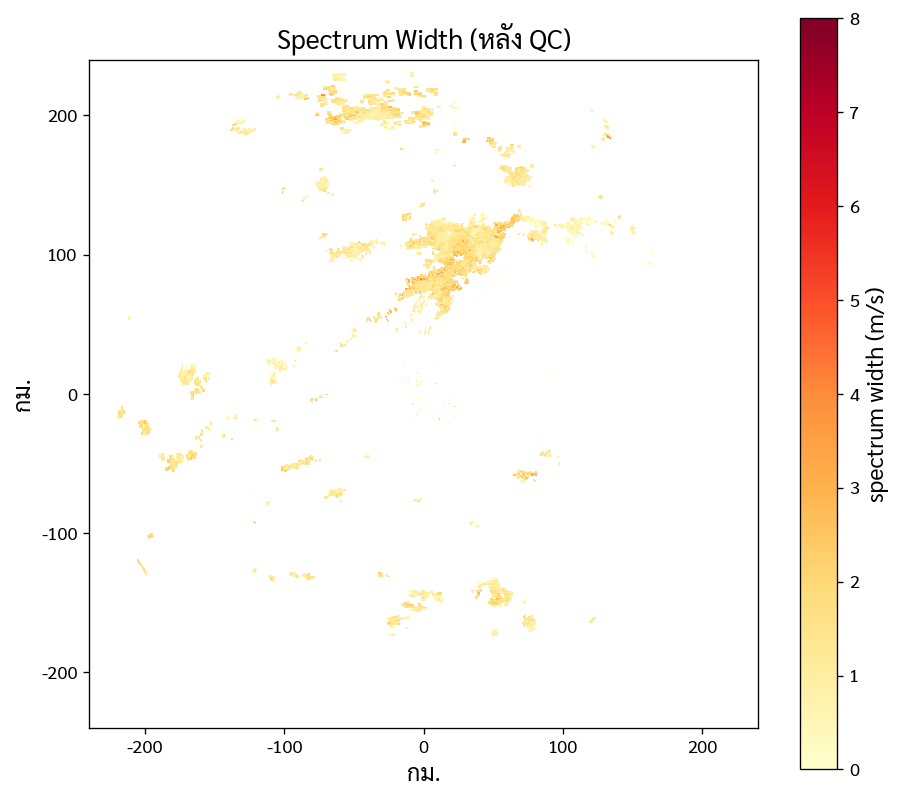

In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))
ppi(ax, 'spectrum_width', vmin=0, vmax=8, cmap='YlOrRd', label='spectrum width (m/s)',
    title='Spectrum Width (หลัง QC)')
plt.tight_layout()
fig.savefig(os.path.join(OUT, 'A1_spectrum_width.png'), dpi=200, bbox_inches='tight')
plt.show()

**การแปลผล:** บริเวณสีเข้ม (SW สูง) = ความเร็วในปริมาตรกระจายมาก → ความปั่นป่วน/แรงเฉือน มักอยู่ตามขอบพายุ แนวปะทะ หรือแกนพาความร้อนรุนแรง


## A2 — เทียบ Reflectivity / Velocity (dealiased) / Spectrum Width

ทั้งสามตัวแปรเล่าเรื่องคนละมุม: **ฝนอยู่ไหน (Z)**, **ลมเข้า/ออก (V)**, **ปั่นป่วนแค่ไหน (SW)**


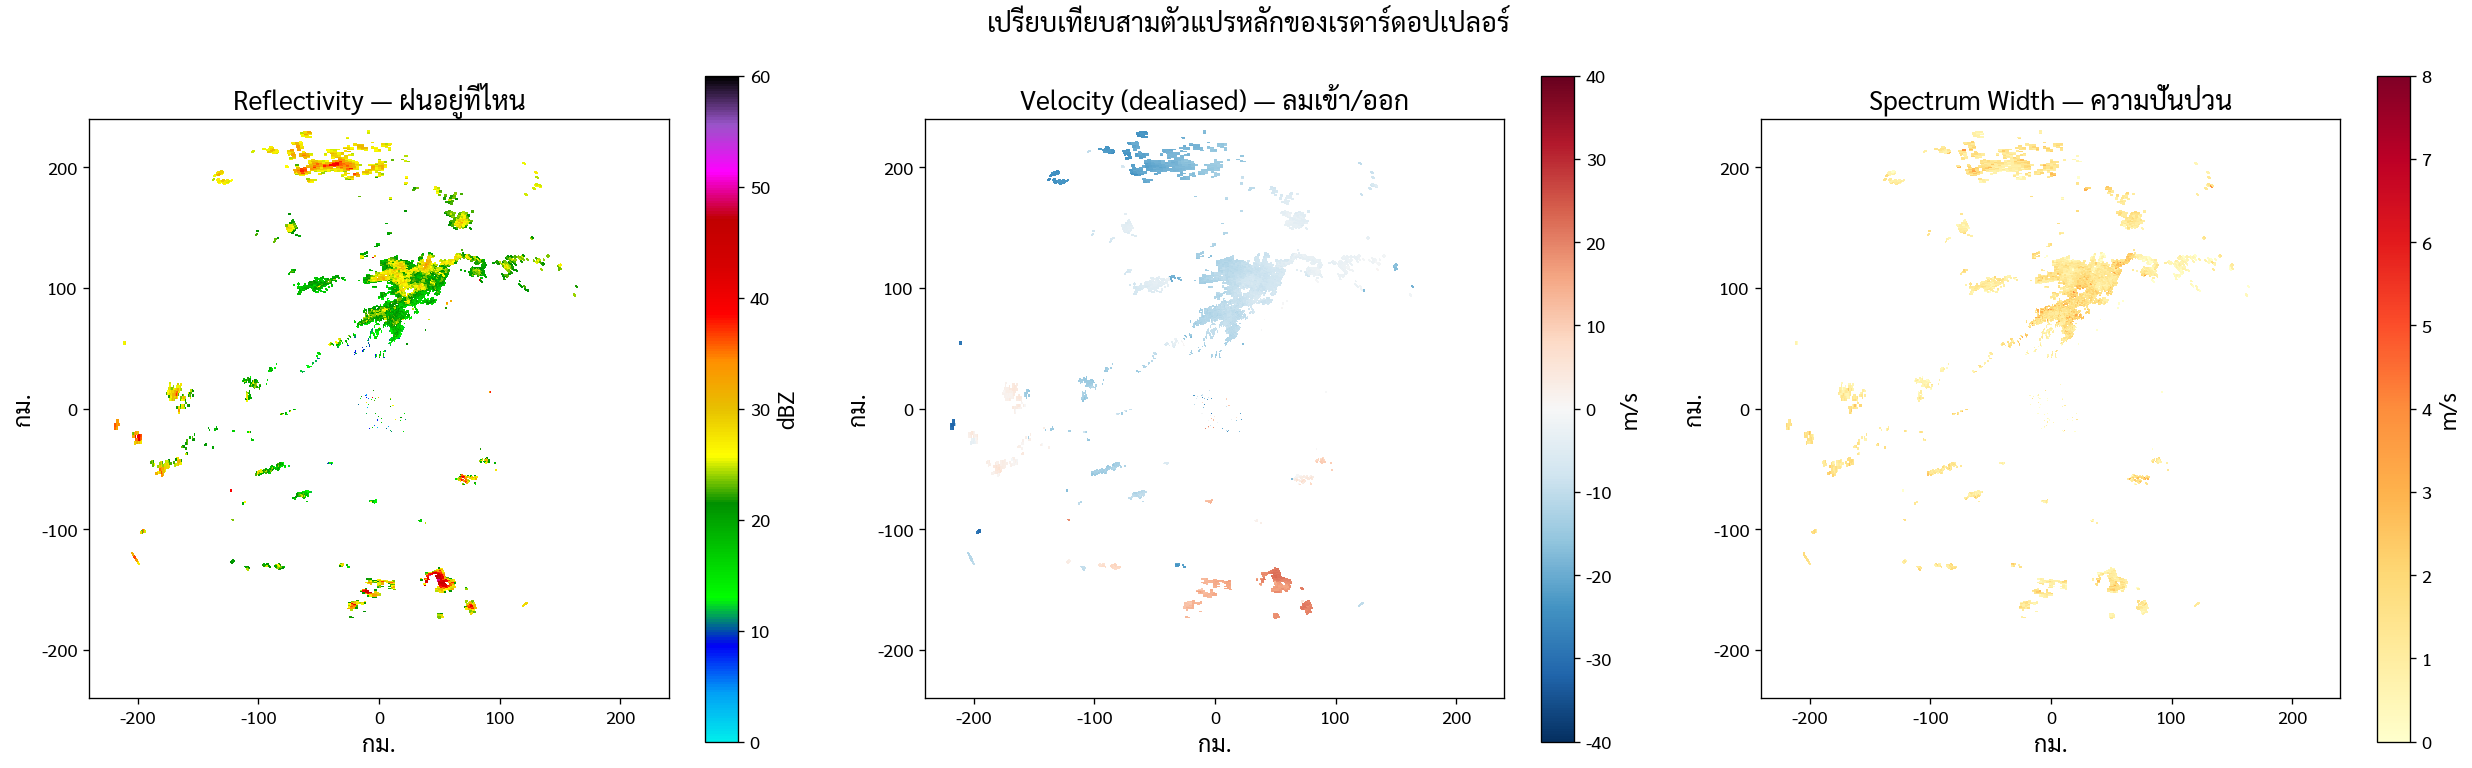

In [ ]:
vlim = float(np.ma.max(np.ma.abs(radar.fields['corrected_velocity']['data'])))
vlim = min(np.ceil(vlim/5)*5, 60)
fig, axes = plt.subplots(1, 3, figsize=(21, 6.5))
ppi(axes[0], 'reflectivity', vmin=0, vmax=60, cmap='NWSRef', label='dBZ', title='Reflectivity — ฝนอยู่ที่ไหน')
ppi(axes[1], 'corrected_velocity', vmin=-vlim, vmax=vlim, cmap='RdBu_r', label='m/s',
    title='Velocity (dealiased) — ลมเข้า/ออก')
ppi(axes[2], 'spectrum_width', vmin=0, vmax=8, cmap='YlOrRd', label='m/s',
    title='Spectrum Width — ความปั่นป่วน')
plt.suptitle('เปรียบเทียบสามตัวแปรหลักของเรดาร์ดอปเปลอร์', fontsize=16)
plt.tight_layout()
fig.savefig(os.path.join(OUT, 'A2_three_fields.png'), dpi=200, bbox_inches='tight')
plt.show()

**การแปลผล:** ให้นิสิตอ่านสามภาพร่วมกัน — บริเวณที่ **velocity เปลี่ยนทิศฉับพลัน** (แดง↔น้ำเงินติดกัน) มักตรงกับ **SW สูง** = แนวเฉือน/แนวปะทะที่อากาศปั่นป่วน แม้ reflectivity อาจไม่สูงมาก


## A3 — บริเวณ SW สูง = ความปั่นป่วน/แรงเฉือน

ไฮไลต์บริเวณ SW เกินเกณฑ์ (เช่น > 4 m/s) และดูความสัมพันธ์ SW กับความแรงฝน


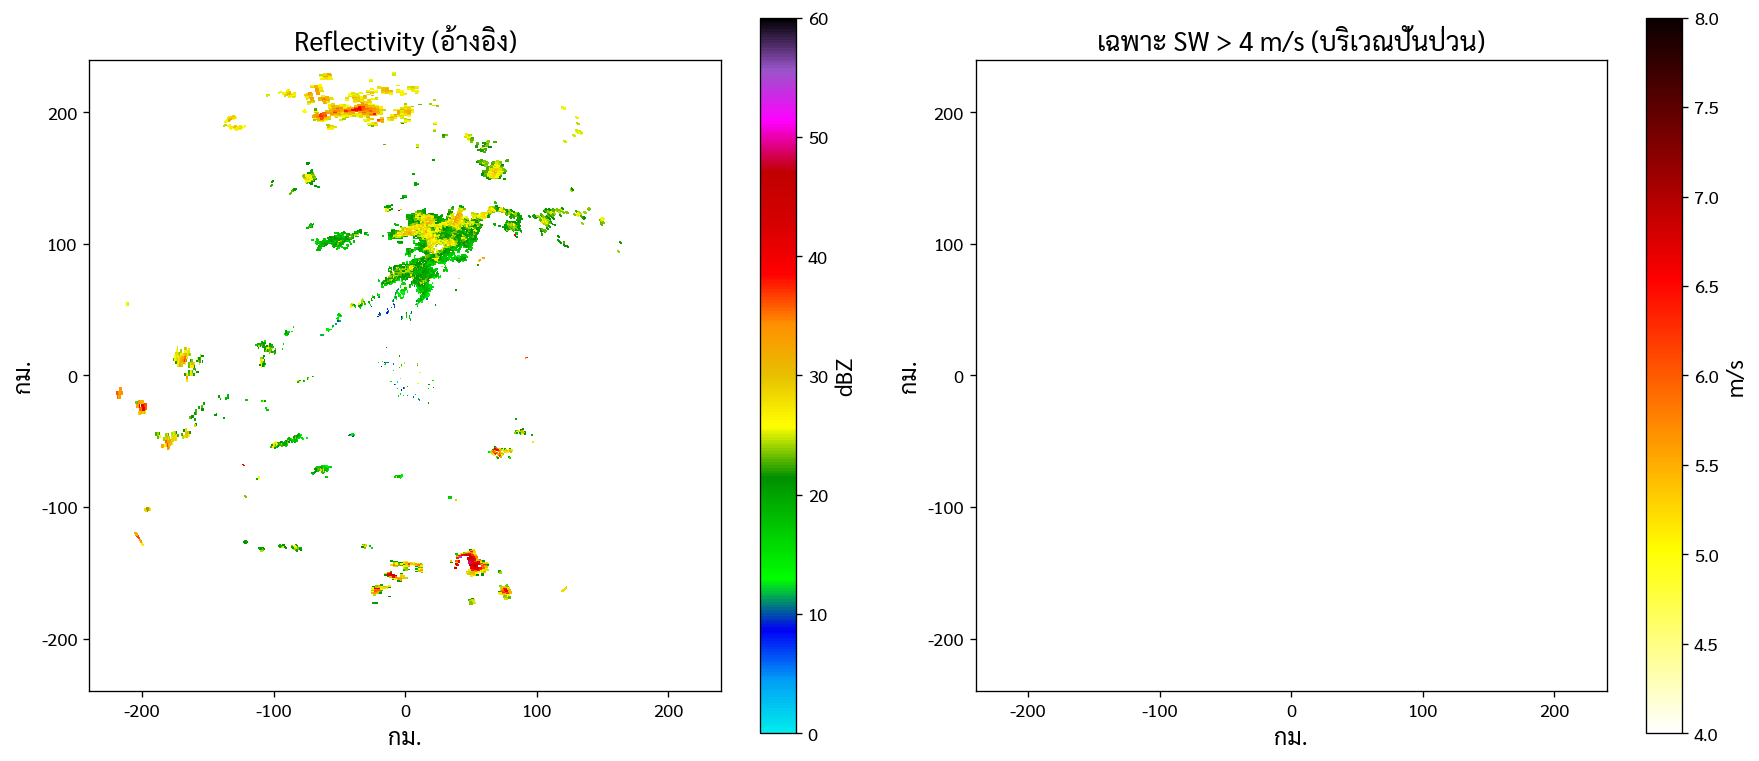

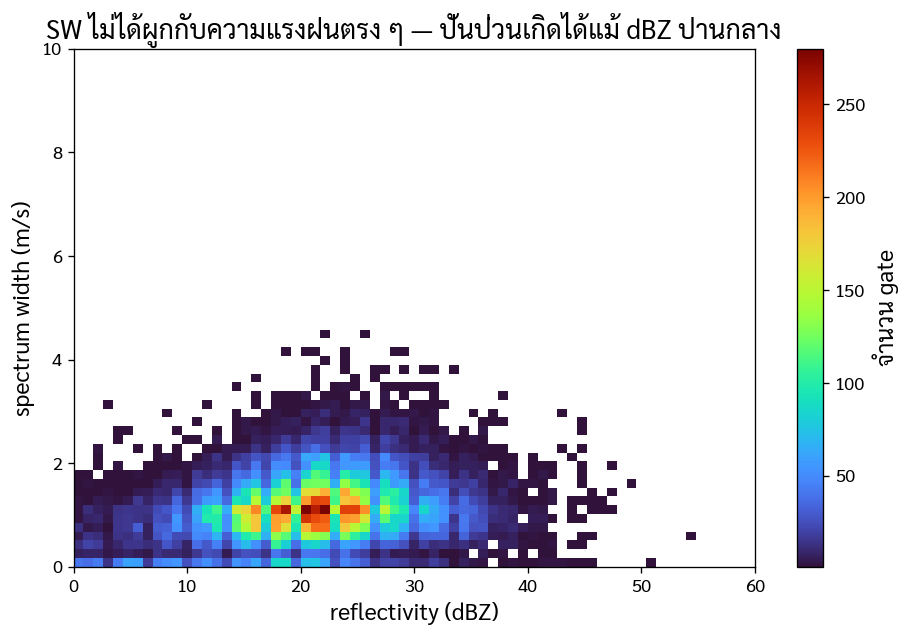

In [ ]:
sw = radar.fields['spectrum_width']['data']
ref = radar.fields['reflectivity']['data']

# แผนที่บริเวณ SW สูง
gf_turb = pyart.filters.GateFilter(radar)
gf_turb.exclude_below('cross_correlation_ratio', 0.80)
gf_turb.exclude_below('spectrum_width', 4.0)
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
ppi(axes[0], 'reflectivity', vmin=0, vmax=60, cmap='NWSRef', label='dBZ', title='Reflectivity (อ้างอิง)')
ppi(axes[1], 'spectrum_width', vmin=4, vmax=8, cmap='hot_r', gfl=gf_turb, label='m/s',
    title='เฉพาะ SW > 4 m/s (บริเวณปั่นป่วน)')
plt.tight_layout(); plt.show()

# ความสัมพันธ์ SW vs reflectivity
s = np.ma.filled(sw, np.nan).ravel(); r = np.ma.filled(ref, np.nan).ravel()
ok = np.isfinite(s) & np.isfinite(r)
fig, ax = plt.subplots(figsize=(8, 5.5))
h = ax.hist2d(r[ok], s[ok], bins=[np.linspace(0,60,70), np.linspace(0,10,60)], cmap='turbo', cmin=1)
ax.set_xlabel('reflectivity (dBZ)'); ax.set_ylabel('spectrum width (m/s)')
ax.set_title('SW ไม่ได้ผูกกับความแรงฝนตรง ๆ — ปั่นป่วนเกิดได้แม้ dBZ ปานกลาง')
plt.colorbar(h[3], ax=ax, label='จำนวน gate'); plt.tight_layout(); plt.show()

**การแปลผล:** SW สูงกระจายในหลายช่วง dBZ — ยืนยันว่า **ความปั่นป่วนเป็นข้อมูลเสริมที่ reflectivity บอกไม่ได้** จึงต้องดู SW ควบคู่


## A4 — ภาพตัดแนวดิ่งของ Spectrum Width (โครงสร้างความปั่นป่วน)


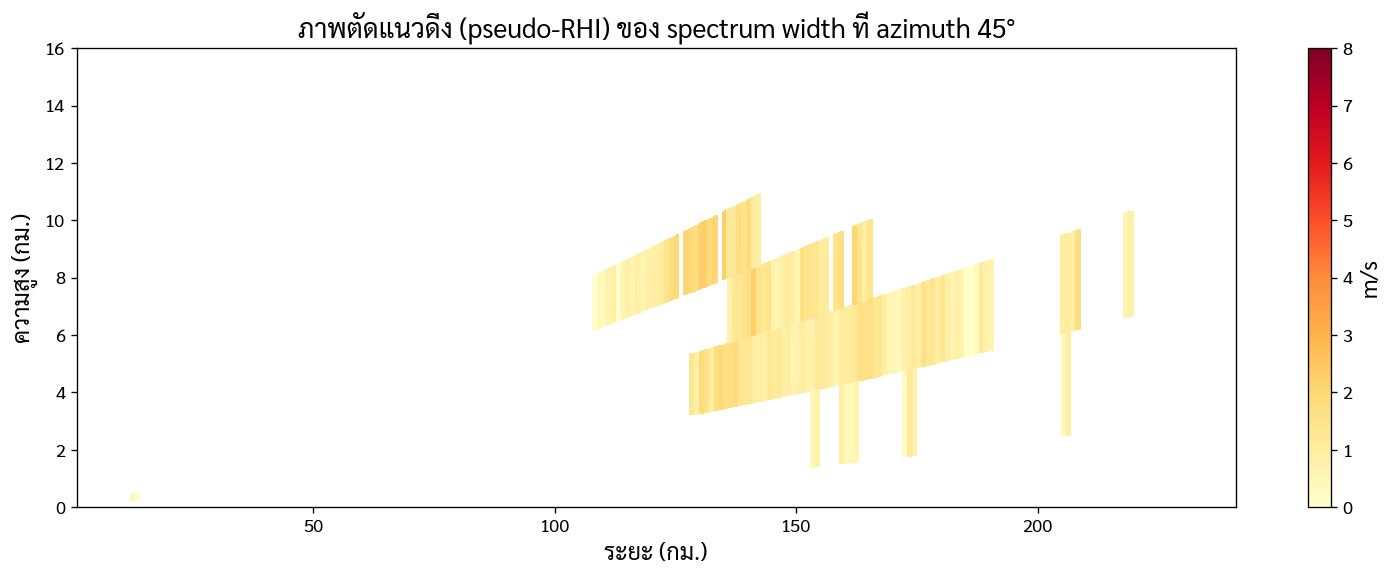

In [ ]:
try:
    rhi = pyart.util.cross_section_ppi(radar, [45.0], az_tol=2.0)
    fig, ax = plt.subplots(figsize=(13, 5))
    d = pyart.graph.RadarDisplay(rhi)
    d.plot('spectrum_width', 0, ax=ax, vmin=0, vmax=8, cmap='YlOrRd', colorbar_label='m/s',
           title='ภาพตัดแนวดิ่ง (pseudo-RHI) ของ spectrum width ที่ azimuth 45°')
    ax.set_ylim(0, 16); ax.set_xlabel('ระยะ (กม.)'); ax.set_ylabel('ความสูง (กม.)')
    plt.tight_layout(); fig.savefig(os.path.join(OUT,'A4_sw_cross.png'), dpi=200, bbox_inches='tight'); plt.show()
except Exception as e:
    print("สร้าง pseudo-RHI ไม่ได้:", repr(e))

**การแปลผล:** เห็นว่าความปั่นป่วนกระจุกที่ระดับ/ระยะใด — แกนพาความร้อนที่พัฒนาแรงมักมี SW สูงในแนวดิ่งชัดเจน


## A5 — PyTDA: คำนวณ EDR ด้วยคำสั่งเดียว ⭐

PyTDA แปลง spectrum width เป็น **EDR$^{1/3}$** (ความปั่นป่วนมาตรฐานการบิน) เพียงบรรทัดเดียว


In [ ]:
RRV = (8.0*np.log(4.0))**0.5
CONST = 1.6 * gamma(2.0/3.0)
def edr13_equation(sw_ms, rng_km, theta_deg, gs_km):
    "แปลง spectrum width -> EDR^(1/3) ตามสมการ (Bohne 1982; ใช้เป็น fallback/สาธิต)"
    beta  = gs_km*1000.0/RRV
    alpha = rng_km*1000.0*np.deg2rad(theta_deg)/RRV
    z = 1.0 - (beta**2/alpha**2)
    series = hyp2f1(-1.0/3.0, 0.5, 2.5, z)
    edr = sw_ms**3 * (1.0/alpha) * (CONST*series)**(-1.5)
    return edr**(1.0/3.0)

if HAS_PYTDA:
    pytda.calc_turb_vol(radar, name_dz='reflectivity', name_sw='spectrum_width',
                        turb_name='turbulence', beamwidth=BEAMWIDTH, gate_spacing=GATE_SP,
                        use_ntda=True, verbose=True)
    print("คำนวณ EDR ด้วย PyTDA (calc_turb_vol) สำเร็จ ✅")
else:
    rng2d = np.broadcast_to(radar.range['data']/1000.0, radar.fields['spectrum_width']['data'].shape)
    swf = np.ma.filled(radar.fields['spectrum_width']['data'], np.nan)
    edr = edr13_equation(swf, rng2d, BEAMWIDTH, GATE_SP)
    edr_m = np.ma.masked_invalid(edr)
    radar.add_field_like('spectrum_width', 'turbulence', edr_m, replace_existing=True)
    print("คำนวณ EDR ด้วยสมการ (fallback) สำเร็จ ✅")

_turb_raw = np.ma.filled(radar.fields['turbulence']['data'], np.nan)
# EDR^(1/3) ต้องไม่เป็นลบตามฟิสิกส์ — คัดค่า sentinel/NaN ที่หลุดรอดจาก PyTDA ออกไป
_turb_finite = _turb_raw[np.isfinite(_turb_raw) & (_turb_raw >= 0)]
_n_invalid_leftover = int(np.isfinite(_turb_raw).sum() - _turb_finite.size)
if _turb_finite.size:
    print("ช่วงค่า EDR^(1/3):", round(float(_turb_finite.min()), 3),
          "ถึง", round(float(_turb_finite.max()), 3),
          f"(gate ที่คำนวณได้จริง {_turb_finite.size:,} จาก {radar.fields['turbulence']['data'].size:,})")
    if _n_invalid_leftover:
        print(f"หมายเหตุ: ตัด sentinel/ค่าผิดปกติ {_n_invalid_leftover} gate ออกจากสถิตินี้ "
              "(ข้อจำกัดที่ทราบของ PyTDA — ไม่ใช่ข้อผิดพลาดของโน้ตบุ๊ก)")
else:
    print("⚠️ ไม่มี gate ที่คำนวณ EDR ได้ (ข้อมูลอาจถูกกรองออกหมด)")

Sweep number: 0
0.04217219352722168 seconds to compute longitudes and precompute Csnr, Crng, Czh
0.6068921089172363 seconds to get eps, reduce data, compute BallTree, and get Cswv
i = 0 of 6182 2.4080276489257812e-05 seconds elapsed during loop
1.4793024063110352 seconds to process radar sweep
Sweep number: 1
0.02572154998779297 seconds to compute longitudes and precompute Csnr, Crng, Czh
0.3302619457244873 seconds to get eps, reduce data, compute BallTree, and get Cswv
i = 0 of 9051 0.0004608631134033203 seconds elapsed during loop
0.6790783405303955 seconds to process radar sweep
Sweep number: 2
0.012587547302246094 seconds to compute longitudes and precompute Csnr, Crng, Czh
0.18149161338806152 seconds to get eps, reduce data, compute BallTree, and get Cswv
i = 0 of 7482 2.9325485229492188e-05 seconds elapsed during loop
0.6075036525726318 seconds to process radar sweep
Sweep number: 3
0.01305389404296875 seconds to compute longitudes and precompute Csnr, Crng, Czh
0.1485595703125 s

## A6 — 4-Panel: Reflectivity / Velocity / Spectrum Width / EDR (แบบ NASA Demo)


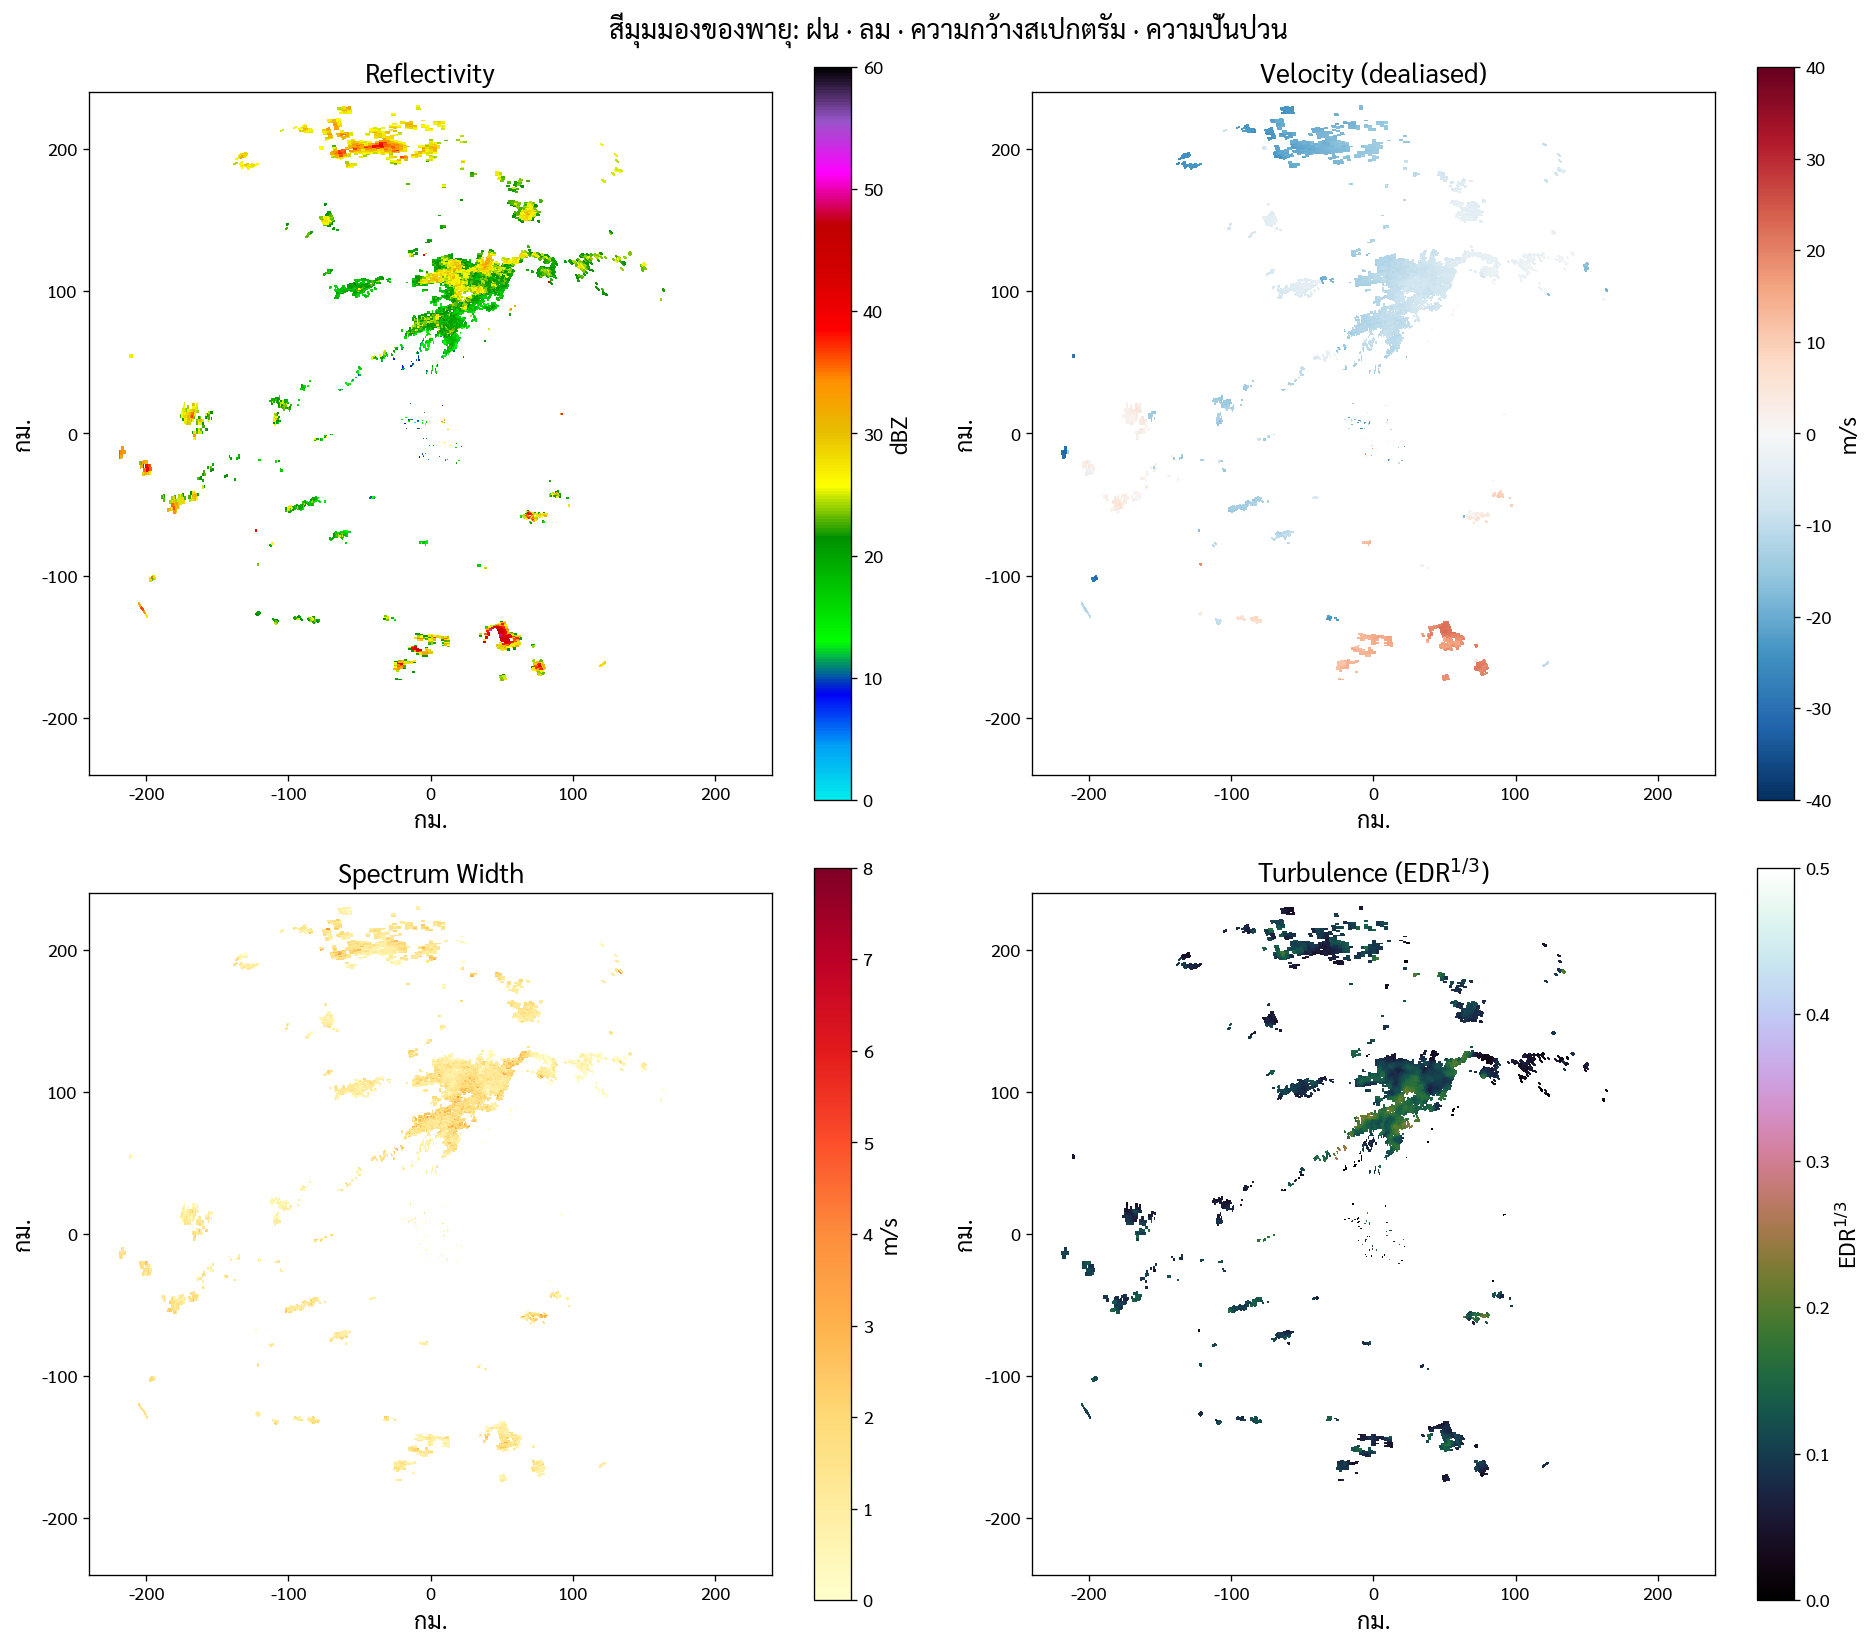

In [ ]:
specs = [('reflectivity', 'NWSRef', 0, 60, 'dBZ', 'Reflectivity'),
         ('corrected_velocity', 'RdBu_r', -vlim, vlim, 'm/s', 'Velocity (dealiased)'),
         ('spectrum_width', 'YlOrRd', 0, 8, 'm/s', 'Spectrum Width'),
         ('turbulence', 'cubehelix', 0, 0.5, 'EDR$^{1/3}$', 'Turbulence (EDR$^{1/3}$)')]
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
for ax, (f, cm, vmn, vmx, lab, ttl) in zip(axes.flat, specs):
    ppi(ax, f, vmin=vmn, vmax=vmx, cmap=cm, label=lab, title=ttl)
plt.suptitle('สี่มุมมองของพายุ: ฝน · ลม · ความกว้างสเปกตรัม · ความปั่นป่วน', fontsize=16)
plt.tight_layout()
fig.savefig(os.path.join(OUT, 'A6_four_panel.png'), dpi=200, bbox_inches='tight')
plt.show()

**การแปลผล:** EDR เป็น "บทสรุป" ของความปั่นป่วน — จุดที่ EDR สูงคือบริเวณอันตรายต่อการบิน มักตรงกับ SW สูงและแนวเฉือนของ velocity


## A7 — จำแนกระดับความปั่นป่วน (เบา / ปานกลาง / รุนแรง)

มาตรฐานการบินโดยประมาณ: EDR$^{1/3}$ < 0.1 เบา, 0.1–0.3 ปานกลาง, 0.3–0.5 รุนแรง, > 0.5 รุนแรงมาก


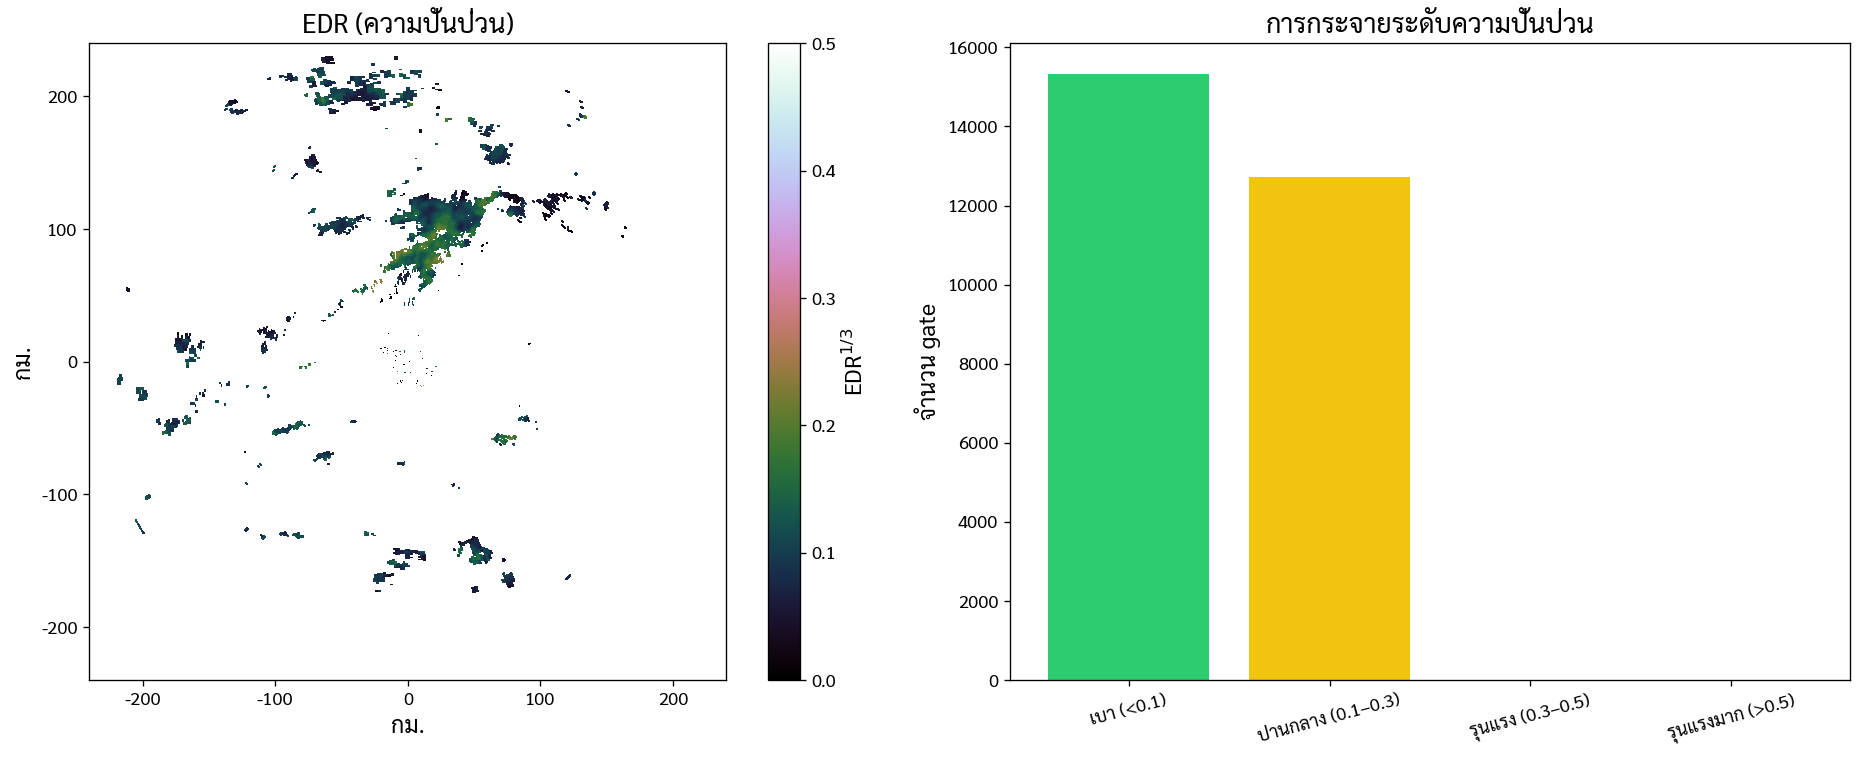

สัดส่วนพื้นที่รุนแรง (EDR>0.3): 0.0 %


In [ ]:
edr_data = radar.fields['turbulence']['data']
levels = [0, 0.1, 0.3, 0.5, np.inf]
labels = ['เบา (<0.1)', 'ปานกลาง (0.1–0.3)', 'รุนแรง (0.3–0.5)', 'รุนแรงมาก (>0.5)']
d = np.ma.filled(edr_data, np.nan).ravel(); d = d[np.isfinite(d)]
counts = [int(((d>=levels[i])&(d<levels[i+1])).sum()) for i in range(4)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
ppi(axes[0], 'turbulence', vmin=0, vmax=0.5, cmap='cubehelix', label='EDR$^{1/3}$', title='EDR (ความปั่นป่วน)')
axes[1].bar(labels, counts, color=['#2ecc71','#f1c40f','#e67e22','#e74c3c'])
axes[1].set_ylabel('จำนวน gate'); axes[1].set_title('การกระจายระดับความปั่นป่วน')
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout()
fig.savefig(os.path.join(OUT, 'A7_turbulence_classes.png'), dpi=200, bbox_inches='tight')
plt.show()
print("สัดส่วนพื้นที่รุนแรง (EDR>0.3):", round(100*sum(counts[2:])/max(sum(counts),1),1), "%")

## A8 — สาธิตสมการ: EDR สัมพันธ์กับ Spectrum Width อย่างไร

ที่ระยะต่างกัน spectrum width เท่ากันให้ EDR ต่างกัน (ปริมาตรตรวจวัดใหญ่ขึ้นตามระยะ)


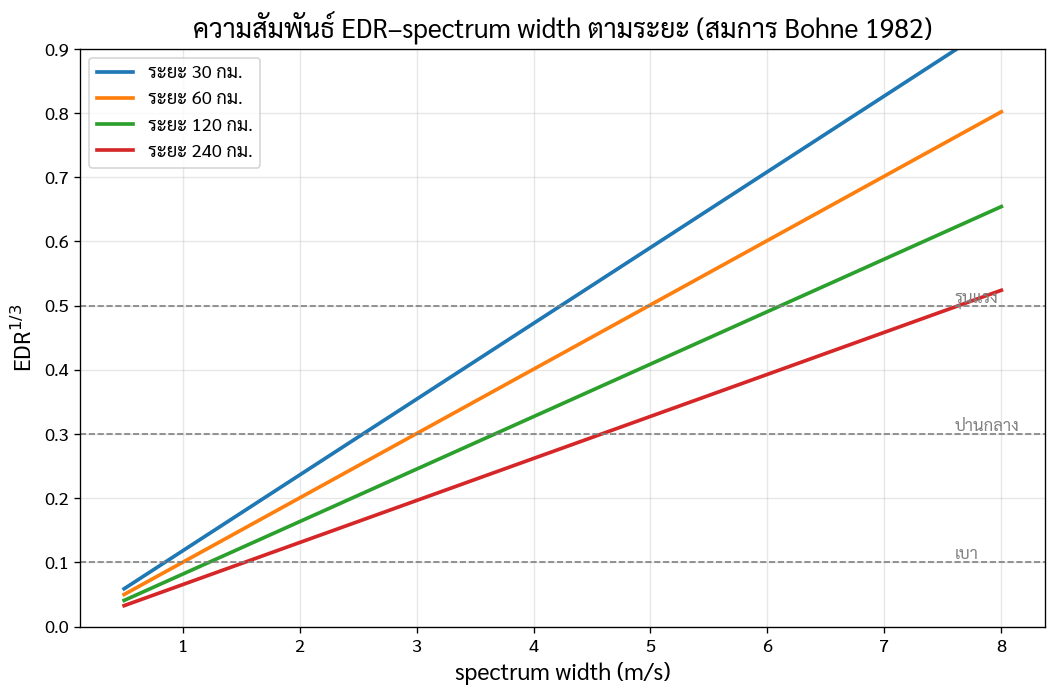

In [ ]:
sw_axis = np.linspace(0.5, 8, 100)
fig, ax = plt.subplots(figsize=(9, 6))
for rng in [30, 60, 120, 240]:
    ax.plot(sw_axis, edr13_equation(sw_axis, rng, BEAMWIDTH, GATE_SP), lw=2.2, label=f'ระยะ {rng} กม.')
for y, lab in [(0.1,'เบา'), (0.3,'ปานกลาง'), (0.5,'รุนแรง')]:
    ax.axhline(y, color='gray', ls='--', lw=1); ax.text(7.6, y+0.005, lab, fontsize=10, color='gray')
ax.set_xlabel('spectrum width (m/s)'); ax.set_ylabel('EDR$^{1/3}$')
ax.set_title('ความสัมพันธ์ EDR–spectrum width ตามระยะ (สมการ Bohne 1982)')
ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(0, 0.9)
plt.tight_layout()
fig.savefig(os.path.join(OUT, 'A8_edr_equation.png'), dpi=200, bbox_inches='tight')
plt.show()

**การแปลผล:** ที่ SW เดียวกัน ระยะใกล้ให้ EDR สูงกว่า เพราะปริมาตรตรวจวัดเล็กกว่า → SW เท่ากันสะท้อนความปั่นป่วนที่เข้มข้นกว่า นี่คือเหตุผลที่ PyTDA ต้องใช้ระยะ/beamwidth/gate spacing ในการแปลง


## A9 — 🎮 เคสให้ทดลอง: เทียบความปั่นป่วน 10:00 vs 10:30

ประมวลผลไฟล์ 10:30 ด้วยขั้นตอนเดียวกัน แล้วเทียบ EDR สองช่วงเวลา — ความปั่นป่วนทวีขึ้นหรือลดลง?


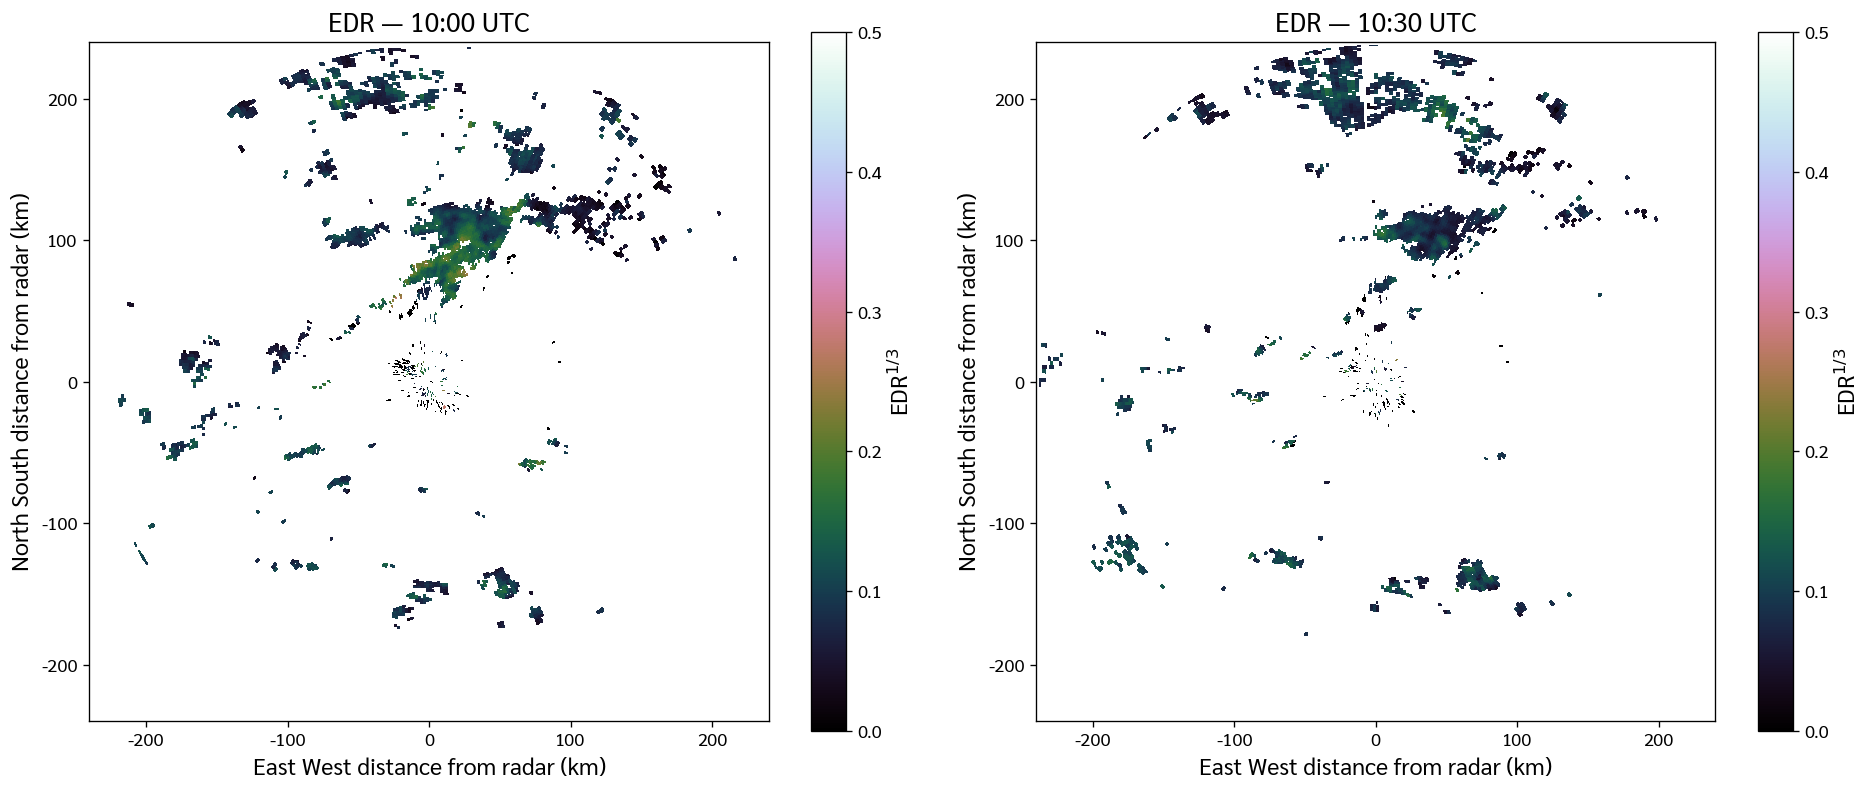

💡 ทดลองต่อ: เปลี่ยน azimuth ของภาพตัด (A4), ปรับเกณฑ์ SW (A3),
   หรือใน A5 ลอง use_ntda=False (เร็วขึ้น) เทียบกับ use_ntda=True (กรองคุณภาพ)


In [ ]:
def process_edr(path):
    r = pyart.io.read(path)
    try: nq = float(r.instrument_parameters['nyquist_velocity']['data'][0])
    except Exception: nq = nyq
    s = pyart.retrieve.calculate_snr_from_reflectivity(r, refl_field='reflectivity', toa=15000.0)
    r.add_field('signal_to_noise_ratio', s, replace_existing=True)
    if HAS_PYTDA:
        pytda.calc_turb_vol(r, beamwidth=BEAMWIDTH, gate_spacing=GATE_SP, use_ntda=True)
    else:
        rng2d = np.broadcast_to(r.range['data']/1000.0, r.fields['spectrum_width']['data'].shape)
        e = edr13_equation(np.ma.filled(r.fields['spectrum_width']['data'], np.nan), rng2d, BEAMWIDTH, GATE_SP)
        r.add_field_like('spectrum_width', 'turbulence', np.ma.masked_invalid(e), replace_existing=True)
    return r

radar_1030 = process_edr(P.RADAR_1030)
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for ax, rr, t in zip(axes, [radar, radar_1030], ['10:00', '10:30']):
    d = pyart.graph.RadarDisplay(rr)
    d.plot('turbulence', 0, ax=ax, vmin=0, vmax=0.5, cmap='cubehelix',
           colorbar_label='EDR$^{1/3}$', title=f'EDR — {t} UTC')
    ax.set_xlim(-240,240); ax.set_ylim(-240,240); ax.set_aspect('equal')
plt.tight_layout()
fig.savefig(os.path.join(OUT, 'A9_edr_time_compare.png'), dpi=200, bbox_inches='tight')
plt.show()
print("💡 ทดลองต่อ: เปลี่ยน azimuth ของภาพตัด (A4), ปรับเกณฑ์ SW (A3),")
print("   หรือใน A5 ลอง use_ntda=False (เร็วขึ้น) เทียบกับ use_ntda=True (กรองคุณภาพ)")

## A10 — ประยุกต์: แผนที่เตือนภัยความปั่นป่วนสำหรับการบิน

รวม EDR เป็นแผนที่ระดับอันตราย ใช้ประกอบการวางแผนเส้นทางบิน/เตือนภัย


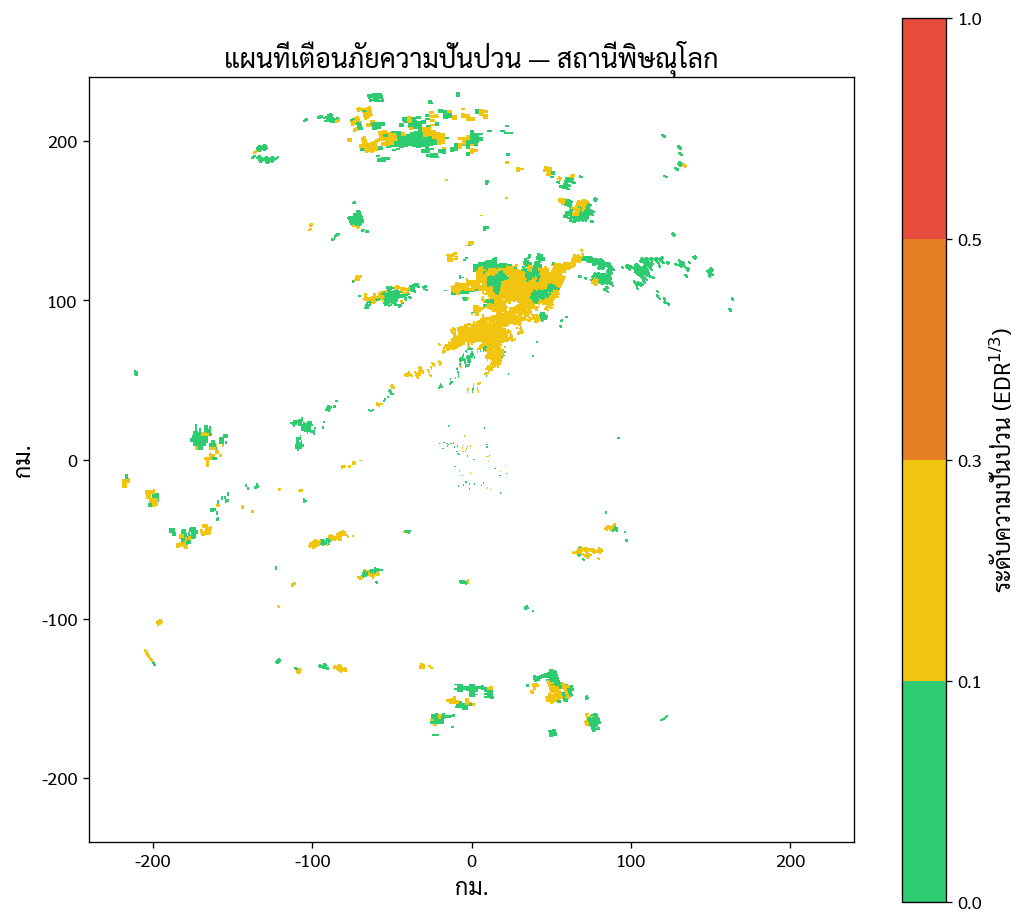

🟢 เบา  🟡 ปานกลาง  🟠 รุนแรง  🔴 รุนแรงมาก


In [ ]:
from matplotlib.colors import BoundaryNorm, ListedColormap
edr0 = radar.fields['turbulence']['data']
d = pyart.graph.RadarDisplay(radar)
cmap = ListedColormap(['#2ecc71','#f1c40f','#e67e22','#e74c3c'])
norm = BoundaryNorm([0,0.1,0.3,0.5,1.0], cmap.N)
fig, ax = plt.subplots(figsize=(9, 8))
d.plot('turbulence', 0, ax=ax, cmap=cmap, norm=norm, gatefilter=gf,
       colorbar_label='ระดับความปั่นป่วน (EDR$^{1/3}$)',
       title='แผนที่เตือนภัยความปั่นป่วน — สถานีพิษณุโลก')
ax.set_xlim(-240,240); ax.set_ylim(-240,240); ax.set_aspect('equal')
ax.set_xlabel('กม.'); ax.set_ylabel('กม.')
plt.tight_layout()
fig.savefig(os.path.join(OUT, 'A10_turbulence_warning.png'), dpi=300, bbox_inches='tight')
plt.show()
print("🟢 เบา  🟡 ปานกลาง  🟠 รุนแรง  🔴 รุนแรงมาก")

## 📝 แบบฝึกหัด

1. เลือก **มุมยก (sweep)** อื่นใน 4-panel (A6) — ความปั่นป่วนที่ระดับสูงต่างจากระดับต่ำอย่างไร?
2. ใน A5 ลอง `use_ntda=False` เทียบ `True` — การกรองคุณภาพแบบ NTDA เปลี่ยนผล EDR อย่างไร?
3. หาบริเวณที่ **velocity เปลี่ยนทิศฉับพลัน** (A2) แล้วตรวจว่าตรงกับ SW/EDR สูงหรือไม่ (แนวเฉือน)
4. (ต่อยอด) เทียบ EDR ที่ได้จาก PyTDA กับสมการที่คำนวณเอง (A5/A8) — ต่างกันเพราะ NTDA ทำ spatial averaging


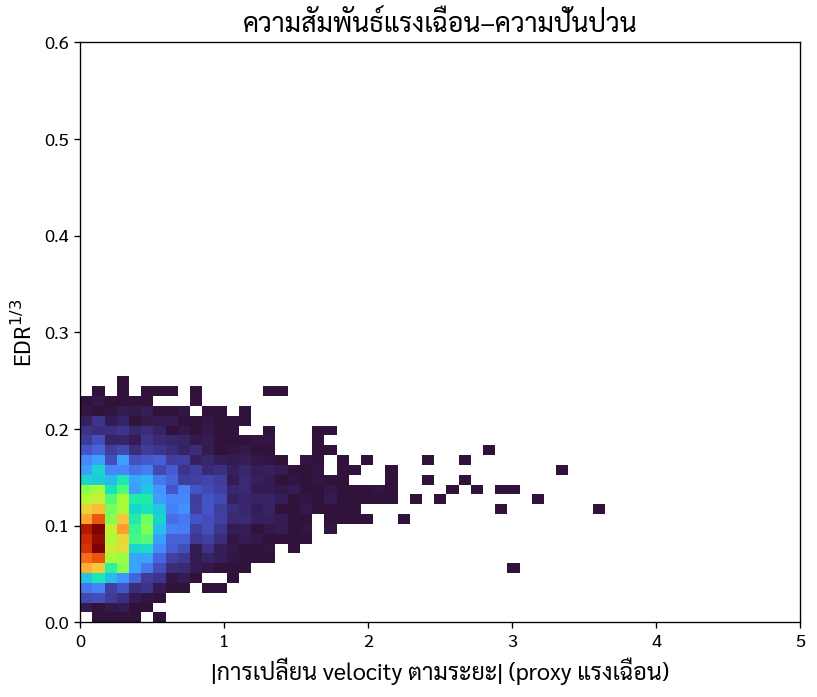

In [ ]:
# แบบฝึกหัดข้อ 3 (โครงเริ่มต้น): scatter EDR vs |gradient ของ velocity| อย่างง่าย
v = np.ma.filled(radar.fields['corrected_velocity']['data'], np.nan)
gv = np.abs(np.gradient(v, axis=1))     # การเปลี่ยนความเร็วตามระยะ (proxy ของ shear)
e = np.ma.filled(radar.fields['turbulence']['data'], np.nan)
ok = np.isfinite(gv.ravel()) & np.isfinite(e.ravel())
fig, ax = plt.subplots(figsize=(7,6))
ax.hist2d(gv.ravel()[ok], e.ravel()[ok], bins=[np.linspace(0,5,60), np.linspace(0,0.6,60)], cmap='turbo', cmin=1)
ax.set_xlabel('|การเปลี่ยน velocity ตามระยะ| (proxy แรงเฉือน)'); ax.set_ylabel('EDR$^{1/3}$')
ax.set_title('ความสัมพันธ์แรงเฉือน–ความปั่นป่วน'); plt.tight_layout(); plt.show()
# TODO (นิสิต): ทำข้อ 1, 2, 4 ต่อ

---
## 🎯 สรุป

- **Spectrum width** วัดการกระจายของความเร็วในปริมาตร → เผยความปั่นป่วน/แรงเฉือนที่ Z/V บอกไม่ได้
- ต้อง **QC + dealias** ก่อนตีความเสมอ และดูสามตัวแปรร่วมกัน
- **PyTDA** แปลง spectrum width เป็น **EDR$^{1/3}$** (มาตรฐานความปั่นป่วนการบิน) ด้วยคำสั่งเดียว
- EDR ขึ้นกับระยะ/beamwidth/gate spacing (สมการ Bohne 1982) — ระยะใกล้ SW เท่ากันให้ EDR สูงกว่า
- ประยุกต์เป็นแผนที่เตือนภัยความปั่นป่วนสำหรับการบินได้

🎓 **นิสิตได้เห็นการใช้ spectrum width ต่อยอดสู่สารสนเทศความปั่นป่วนเชิงปฏิบัติการ ครบวงจรกับ QC และ dealiasing ที่เรียนมา**
